In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [62]:
# Load Data
df = pd.read_csv(r"../data/store_customers.csv")

In [63]:
df.shape

(1000, 5)

In [64]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [65]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [66]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [67]:
df["Gender"].value_counts()

Gender
F    522
M    475
Name: count, dtype: int64

In [68]:
print(df.groupby('Gender')['Age'].mean(), end="\n\n")

print(df.groupby('Gender')['Annual Income (k$)'].mean(), end="\n\n")

print(df.groupby('Gender')['Spending Score (1-100)'].mean(), end="\n\n")

Gender
F    39.110039
M    38.742072
Name: Age, dtype: float64

Gender
F    57.798649
M    56.433053
Name: Annual Income (k$), dtype: float64

Gender
F    42.273603
M    43.082452
Name: Spending Score (1-100), dtype: float64



Text(0.5, 1.0, 'Spending Score by Gender')

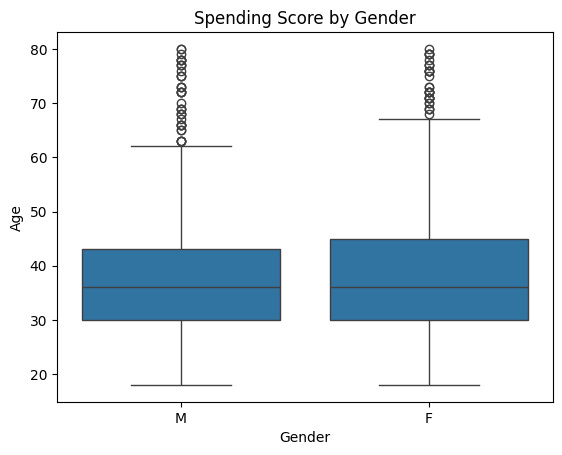

In [69]:
sns.boxplot(data=df, x='Gender', y="Age") # There is outlier in Age column

plt.title("Spending Score by Gender")

Text(0.5, 1.0, 'Spending Score by Gender')

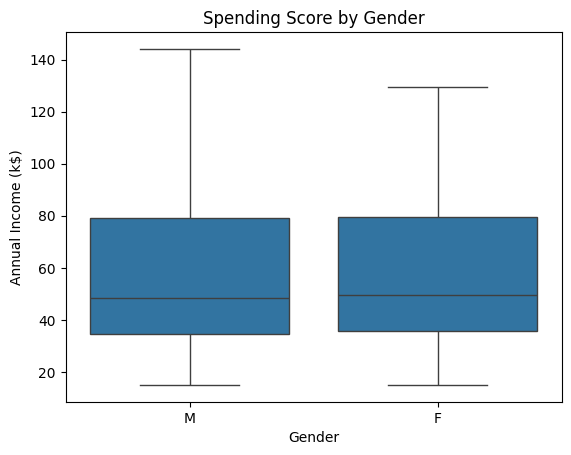

In [70]:
sns.boxplot(data=df, x='Gender', y="Annual Income (k$)")

plt.title("Spending Score by Gender")

Text(0.5, 1.0, 'Spending Score by Gender')

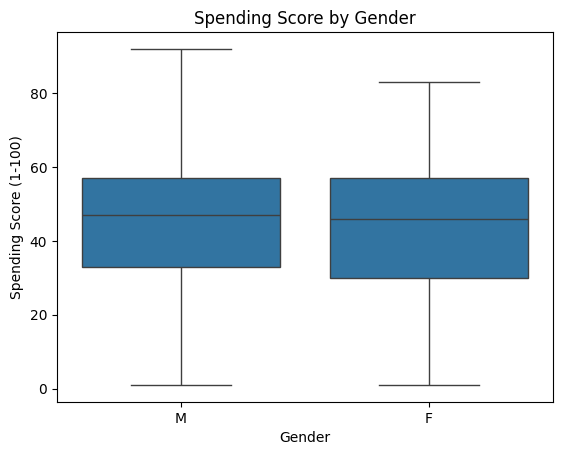

In [71]:
sns.boxplot(data=df, x='Gender', y="Spending Score (1-100)")

plt.title("Spending Score by Gender")

Text(0.5, 1.0, 'Spending Distribution by Gender')

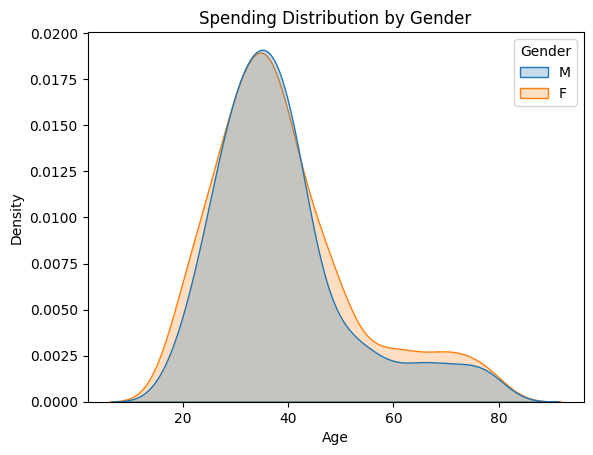

In [72]:
sns.kdeplot(data=df, x='Age', hue='Gender', fill=True)
plt.title("Spending Distribution by Gender")

Text(0.5, 1.0, 'Spending Distribution by Gender')

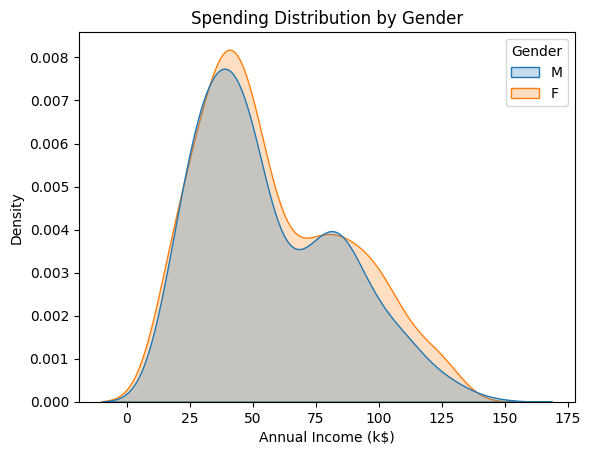

In [73]:
sns.kdeplot(data=df, x='Annual Income (k$)', hue='Gender', fill=True)
plt.title("Spending Distribution by Gender")

Text(0.5, 1.0, 'Spending Distribution by Gender')

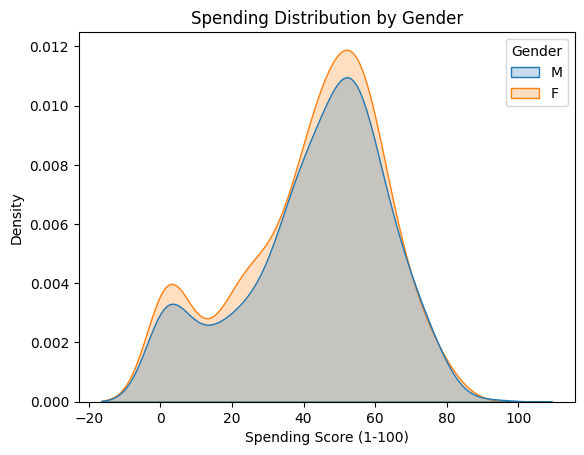

In [74]:
sns.kdeplot(data=df, x='Spending Score (1-100)', hue='Gender', fill=True)
plt.title("Spending Distribution by Gender")

In [75]:
df = df.drop(columns=["CustomerID", "Gender"])
df.shape

(1000, 3)

<Axes: xlabel='Age', ylabel='Density'>

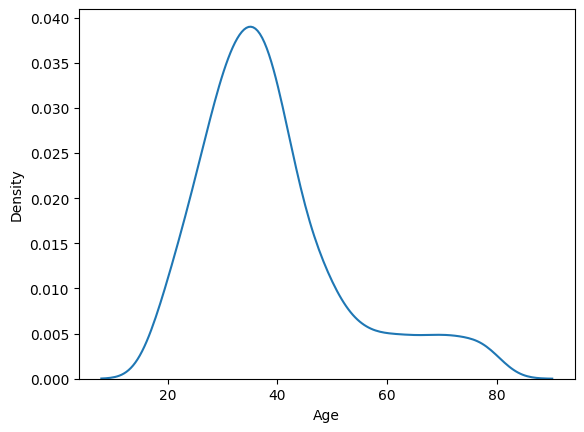

In [76]:
sns.kdeplot(df['Age'])

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

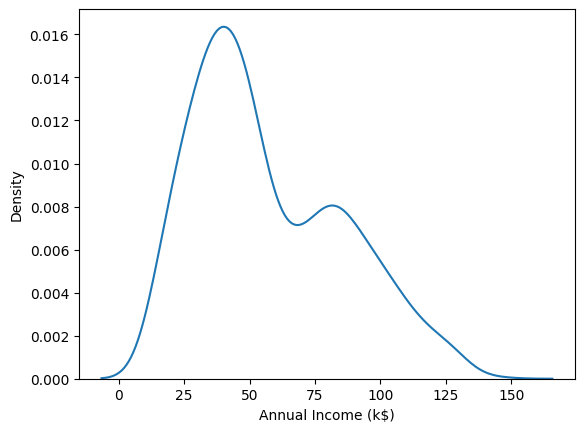

In [77]:
sns.kdeplot(df["Annual Income (k$)"])

<Axes: xlabel='Spending Score (1-100)', ylabel='Density'>

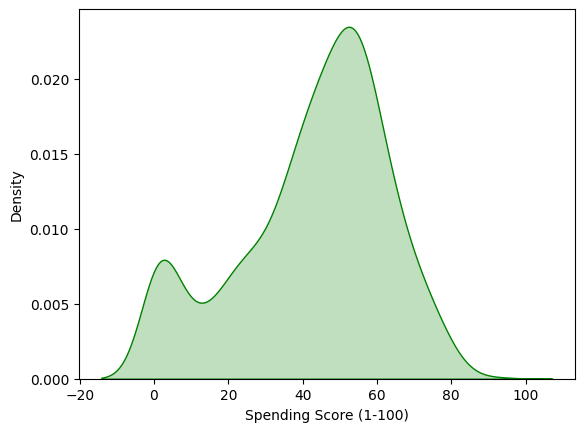

In [78]:
sns.kdeplot(data=df, x=df["Spending Score (1-100)"], fill=True, color="green")

In [79]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(df["Annual Income (k$)"].median())
df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(df["Spending Score (1-100)"].median())

In [80]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [81]:
X = df.iloc[:,:].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i)
    km.fit_predict(X_scaled)
    wcss.append(km.inertia_)

In [82]:
wcss

[2999.9999999999995,
 1042.867000119175,
 612.1178747352025,
 452.7526264005424,
 390.3816441591316,
 334.32852421019163,
 286.7714998685636,
 249.259313850348,
 253.973971865914,
 212.90085442131553]

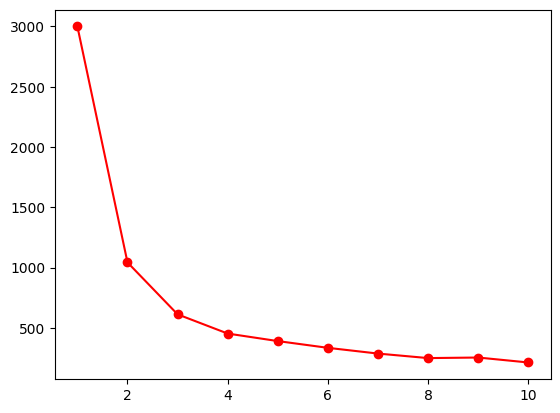

In [83]:
plt.plot(range(1,11), wcss, marker="o", color="red")

In [84]:
km = KMeans(n_clusters=4)
labels = km.fit_predict(X_scaled)
centroids = km.cluster_centers_

In [85]:
labels

array([1, 1, 3, 3, 0, 0, 3, 3, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 3, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 3, 1, 0, 1, 0, 1, 0, 0, 1, 3, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 3, 3, 3, 0, 1, 1, 3, 0, 1, 0, 0, 1, 3,
       0, 3, 1, 0, 1, 3, 0, 3, 0, 1, 1, 1, 0, 0, 1, 1, 3, 0, 1, 0, 3, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 3, 1, 1, 0,
       0, 1, 1, 2, 0, 1, 1, 0, 3, 3, 3, 0, 3, 0, 3, 2, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 3, 0, 1, 1, 0, 1, 3, 0, 3, 0, 1, 0, 1, 3, 1, 1, 1, 0, 1,
       1, 0, 3, 1, 0, 3, 0, 3, 3, 0, 3, 1, 3, 3, 0, 0, 0, 0, 1, 1, 1, 3,
       1, 3, 0, 2, 1, 0, 0, 1, 0, 3, 1, 1, 0, 0, 1, 3, 1, 0, 3, 1, 0, 0,
       1, 0, 0, 1, 3, 3, 0, 0, 1, 0, 1, 2, 3, 3, 1, 1, 1, 3, 0, 1, 1, 0,
       2, 0, 1, 0, 1, 3, 1, 0, 1, 1, 0, 1, 0, 0, 3, 1, 0, 0, 0, 1, 1, 0,
       3, 3, 0, 1, 0, 0, 3, 1, 0, 3, 3, 3, 0, 0, 3, 0, 1, 3, 0, 0, 0, 0,
       1, 0, 3, 0, 0, 1, 3, 0, 3, 0, 1, 1, 1, 0, 1, 0, 1, 3, 3, 0, 3, 0,
       1, 1, 1, 1, 0, 0, 1, 3, 1, 0, 3, 1, 3, 3, 0,

In [86]:
centroids 

array([[-0.83874101, -0.94601827,  0.86276861],
       [-0.22663691, -0.23549648,  0.21944384],
       [ 2.08684183,  1.77385135, -1.88276794],
       [ 0.47879298,  0.86767349, -0.63447478]])

In [87]:
pd.DataFrame(labels).value_counts()

0
0    346
1    321
3    206
2    127
Name: count, dtype: int64

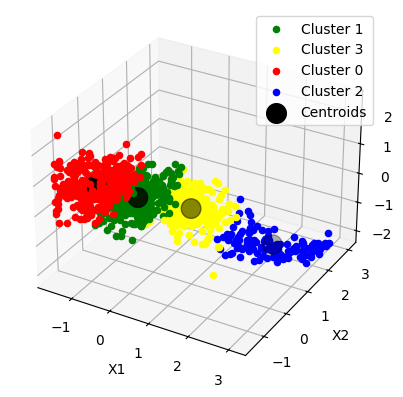

In [88]:
from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 🔷 Plot data points
for i in range(len(labels)):
    if labels[i] == 0:
        ax.scatter(X_scaled[i][0], X_scaled[i][1], X_scaled[i][2],
                   color='red', label='Cluster 0')

    elif labels[i] == 1:
        ax.scatter(X_scaled[i][0], X_scaled[i][1], X_scaled[i][2],
                   color='green', label='Cluster 1')
    
    elif labels[i] == 2:
        ax.scatter(X_scaled[i][0], X_scaled[i][1], X_scaled[i][2],
                   color='blue', label='Cluster 2')
    
    elif labels[i] == 3:
        ax.scatter(X_scaled[i][0], X_scaled[i][1], X_scaled[i][2],
                   color='yellow', label='Cluster 3')

# 🔥 Plot centroids (IMPORTANT)
ax.scatter(centroids[:,0],
           centroids[:,1],
           centroids[:,2],
           color='black',
           s=200,            # size big
           marker='o',       # X shape
           label='Centroids')

# Axis labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')

# Remove duplicate legends
handles, labels_unique = ax.get_legend_handles_labels()
by_label = dict(zip(labels_unique, handles))
ax.legend(by_label.values(), by_label.keys())

plt.show()